# Duck: Cross-shore time series of shoreline changes as intersection of RTS-DTM with horizontal plane at sea level

## Imports

In [1]:
%load_ext autoreload
%autoreload 2
    
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
from scipy.interpolate import griddata

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap

from coastal_data import CD_jarkus_tools, CD_helper_functions, CD_statistics

/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 23
BIGGER_SIZE = 25

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## Paths

In [3]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_rtsdtm = path_to_data_folder+'22_23_Duck_DEM/output/'
path_input_general = path_to_data_folder+'0_input_general/'
path_altimetry_input = path_to_data_folder+'21_Duck_altimetry/input/'
path_altimetry_output = path_to_data_folder+'21_Duck_altimetry/output/'

In [4]:
epsg_local = 32618

## Get RTS-DTM on validation transects

In [5]:
fn_rtsdtm = 'x_state_s_readd.pkl'
x_state_s = pickle.load(open(path_rtsdtm + fn_rtsdtm, 'rb'))

In [6]:
vali_gdf = gpd.read_file(path_rtsdtm + 'duck_vali_gdf.geojson')

In [7]:
rts_gdf = gpd.GeoDataFrame(index=vali_gdf.index, columns=vali_gdf.columns)
rts_gdf.geometry = vali_gdf.geometry

year_list = [int(col.split('_')[-1]) for col in x_state_s.columns if col.startswith('x_s_')]
# year = year_list[0]
for year in year_list:
    mx = x_state_s.geometry.x
    my = x_state_s.geometry.y
    values = x_state_s[f'x_s_{year}']
    interp = griddata(list(zip(mx,my)), values, (vali_gdf.geometry.x,vali_gdf.geometry.y), 'linear')
    rts_gdf[str(year)] = interp

### Remove height difference rts-vali
Bring validation data to SLA -> no need to reduce altimetry to TG then  
would be better to consider only differences in the shoreline area

In [8]:
diff = rts_gdf.drop(columns=['geometry']) - vali_gdf.drop(columns=['geometry'])

print(f'Mean of all differences (RTS - validation): {round(diff.mean().mean(), 2)}, median: {round(diff.median().median(), 2)}')
bias = diff.median().median()
vali_gdf_red = vali_gdf.copy()
vali_gdf_red.loc[:, vali_gdf_red.columns != 'geometry'] += bias

Mean of all differences (RTS - validation): -0.11, median: 0.7


### Separate into profiles

In [9]:
profiles_vali = {}
profiles_rts = {}

n_prof = 76 # number of points per profile

for profile in range(0,51):
    point_start = profile * n_prof
    point_end = profile * n_prof + n_prof - 1
    profiles_rts[str(profile)] = rts_gdf.loc[point_start:point_end]
    profiles_vali[str(profile)] = vali_gdf_red.loc[point_start:point_end]

In [10]:
# Add cross-shore distance
for key in profiles_rts.keys():
    coords_local = profiles_rts[key].geometry.to_crs(epsg_local)
    profiles_rts[key]['cross_shore'] = coords_local.distance(coords_local.shift(1), align=False).cumsum()
    profiles_vali[key]['cross_shore'] = coords_local.distance(coords_local.shift(1), align=False).cumsum()

/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

### Plot profiles

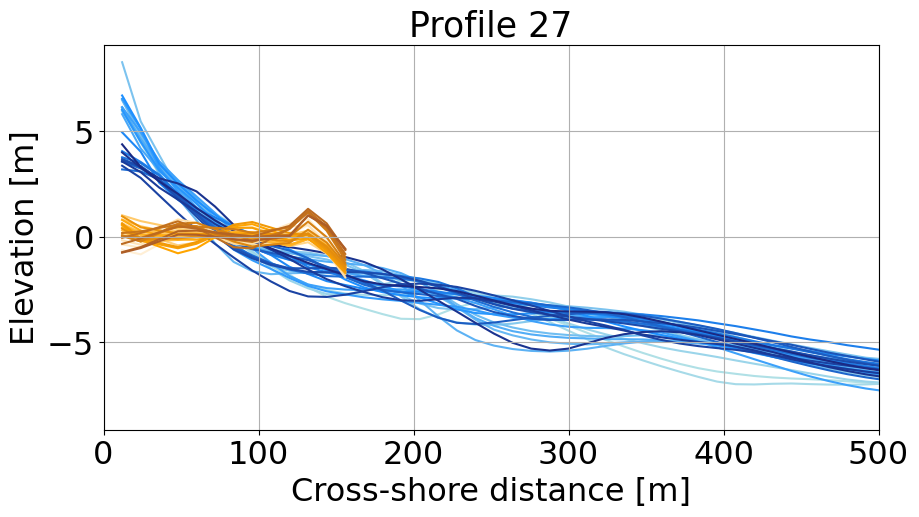

In [11]:
fig, ax = plt.subplots(figsize=(10,5))

profile_to_plot = '27'
profile_rts = profiles_rts[profile_to_plot].drop(columns=['geometry', 'cross_shore'])
profile_vali = profiles_vali[profile_to_plot].drop(columns=['geometry', 'cross_shore'])

blues = ["powderblue", "dodgerblue", "midnightblue"]
cmap_blues = LinearSegmentedColormap.from_list("mycmap", blues).resampled(profiles_rts['0'].shape[1])
oranges = ["papayawhip", "orange", "sienna"]
cmap_oranges = LinearSegmentedColormap.from_list("mycmap", oranges).resampled(profiles_rts['0'].shape[1])

for i, year in enumerate(profile_rts.columns):
    ax.plot(profiles_rts[profile_to_plot].cross_shore, profile_rts[year], c=cmap_oranges(i), zorder=1)
    ax.plot(profiles_rts[profile_to_plot].cross_shore, profile_vali[year], c=cmap_blues(i), zorder=0)
    
ax.grid()
ax.set_title(f'Profile {profile_to_plot}')

ax.set_xlim([0,500])

ax.set_xlabel('Cross-shore distance [m]')
ax.set_ylabel('Elevation [m]')
    
legend_elements = [
        Line2D([0], [0], color=cmap_blues(0), label='Validation 1993'),
        Line2D([0], [0], color=cmap_blues(profiles_rts['0'].shape[1]), label='Validation 2020'),
        Line2D([0], [0], color=cmap_oranges(0), label='RTS-DTM 1993'),
        Line2D([0], [0], color=cmap_oranges(profiles_rts['0'].shape[1]), label='RTS-DTM 2020'),
    ]
# ax.legend(handles=legend_elements, bbox_to_anchor=(1.5,1))

plt.savefig(f'{path_rtsdtm}Duck_profile_examplePlot.png', dpi=300, bbox_inches='tight')



In [12]:
fig = plt.figure(figsize=[20,150])
fig.tight_layout()
gs = gridspec.GridSpec(len(profiles_rts),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)

# key = '0'
for key in profiles_rts.keys():
    profile_rts = profiles_rts[key].drop(columns=['geometry', 'cross_shore'])
    profile_vali = profiles_vali[key].drop(columns=['geometry', 'cross_shore'])
    ax = fig.add_subplot(gs[int(key),0])
    
    # year = profile_rts.columns[0]
    for i, year in enumerate(profile_rts.columns):
        ax.plot(profiles_rts[key].cross_shore, profile_rts[year], c=cmap_oranges(i), zorder=1)
        ax.plot(profiles_vali[key].cross_shore, profile_vali[year], c=cmap_blues(i), zorder=0)
    
    ax.grid()
    ax.set_title(f'Profile {key}')
legend_elements = [
        Line2D([0], [0], color=cmap_blues(0), label='Validation 1993'),
        Line2D([0], [0], color=cmap_blues(profiles_rts['0'].shape[1]), label='Validation 2020'),
        Line2D([0], [0], color=cmap_oranges(0), label='RTS-DTM 1993'),
        Line2D([0], [0], color=cmap_oranges(profiles_rts['0'].shape[1]), label='RTS-DTM 2020'),
    ]
ax.legend(handles=legend_elements, bbox_to_anchor=(1,1))

## Get sea level

In [13]:
# altimetry
fn = 'tp_plus_ales_epsg32618.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])
alt_yearly = alt['sla'].groupby(pd.Grouper(freq='YE')).mean()

In [14]:
# tide gauge to get to the same height reference as jarkus
fn = 'psmsl_monthly_RLR_DUCK.txt'
tg_psmsl_orig = pd.read_csv(f'{path_altimetry_input}/{fn}', sep=';', header=None, names=['date', 'SSH_RLR[mm]'])

tg_psmsl = pd.DataFrame()
tg_psmsl['date'] = CD_helper_functions.decimal_numbers_to_datetime(tg_psmsl_orig['date'])
tg_psmsl = tg_psmsl.set_index('date')

tg_psmsl['SSH_RLR[m]'] = tg_psmsl_orig['SSH_RLR[mm]'].values / 1000 - 6.993
# if absolute ssh needed, convert RLR to benchmark: https://psmsl.org/data/obtaining/rlr.diagrams/1636.php

# reduce to altimetry time period
tg_psmsl = tg_psmsl.iloc[np.nonzero(tg_psmsl.index.year >= 1992)[0]]

# remove 9999.0
idx, = np.where(tg_psmsl['SSH_RLR[m]'] < 10)
tg_psmsl = tg_psmsl.iloc[idx]

# yearly averages
tg_psmsl_yearly = tg_psmsl.groupby(pd.Grouper(freq='YE')).mean()

## Get intersections

In [15]:
def get_intersection(profiles, alt_yearly_red, static_profile=False, static_seaLevel=False):
    years = rts_gdf.drop(columns='geometry').columns.values.astype('int')
    cd_df = pd.DataFrame(index=profiles.keys(),
                         columns=years)

    if static_seaLevel == True:
        ssh = 0
        
    for key in profiles.keys():
        transect = profiles[key]

        for year in years:
            if static_profile == True:
                profile = transect['1993']
            else:
                profile = transect[str(year)]
            
            idx_time, = np.where(alt_yearly_red.index.year == year)
            ssh = alt_yearly_red.iloc[idx_time].values   
            
            intersections = CD_jarkus_tools.find_intersections(profile, ssh, transect.cross_shore.values)
            DuneTop_prim_x = CD_jarkus_tools.find_primary_dunetop(profile, transect.cross_shore.values)
            cd = CD_jarkus_tools.identify_coastline(intersections, DuneTop_prim_x)
            
            cd_df.loc[key, year] = cd
    return cd_df

In [16]:
# RTS-DTM
# Time-variable profile, time-variable sea level
cd_rts_variable = get_intersection(profiles_rts, alt_yearly, static_profile=False, static_seaLevel=False)
# Time-variable profile, static sea level
cd_rts_static_sl = get_intersection(profiles_rts, alt_yearly, static_profile=False, static_seaLevel=True)
# Static profile, time-variable sea level
cd_rts_static_profile = get_intersection(profiles_rts, alt_yearly, static_profile=True, static_seaLevel=False)

In [17]:
# Validation
# Time-variable profile, time-variable sea level
cd_vali_variable = get_intersection(profiles_vali, alt_yearly, static_profile=False, static_seaLevel=False)
# Time-variable profile, static sea level
cd_vali_static_sl = get_intersection(profiles_vali, alt_yearly, static_profile=False, static_seaLevel=True)
# Static profile, time-variable sea level
cd_vali_static_profile = get_intersection(profiles_vali, alt_yearly, static_profile=True, static_seaLevel=False)

## Trends

In [18]:
def get_shoreline_trends(cd):
    trend_df = pd.DataFrame(index=cd.index, columns=['trend', 'Cxx', 'v'])
    x = cd.columns.values.astype(int)
    
    n_nonNanValues = 5 # minimum number of non-NaN values per time series
    
    # transect = cd.index[0]
    for transect in cd.index:
        ts = cd.loc[transect].values.astype('float')
        
        if np.all(np.isnan(ts)):
            continue
        nr_non_nan = len(ts) - np.isnan(ts).sum() # number of non nan values
        if nr_non_nan < n_nonNanValues:
            continue
        else:
            trend_df.loc[transect, 'trend'], trend_df.loc[transect, 'Cxx'], trend_df.loc[transect, 'v'] = CD_statistics.compute_trend_with_error(x, ts)
    return trend_df

In [19]:
trend_rts_variable = get_shoreline_trends(cd_rts_variable)
trend_rts_static_sl = get_shoreline_trends(cd_rts_static_sl)
trend_rts_static_profile = get_shoreline_trends(cd_rts_static_profile)

In [20]:
trend_vali_variable = get_shoreline_trends(cd_vali_variable)
trend_vali_static_sl = get_shoreline_trends(cd_vali_static_sl)
trend_vali_static_profile = get_shoreline_trends(cd_vali_static_profile)

In [21]:
print(f'Average trends, validation data set:')
print(f'1) Variable profile and variable sea level:')
print(f'{round(trend_vali_variable.trend.mean(),2)} m/year (mean), {round(trend_vali_variable.trend.median(),2)} m/year (median)')

print(f'\n2) Variable profile and static sea level:')
print(f'{round(trend_vali_static_sl.trend.mean(),2)} m/year (mean), {round(trend_vali_static_sl.trend.median(),2)} m/year (median)')

print(f'\n3) Static profile and variable sea level:')
print(f'{round(trend_vali_static_profile.trend.mean(),2)} m/year (mean), {round(trend_vali_static_profile.trend.median(),2)} m/year (median)')

print(f'\n\nAverage trends, RTS-DTM:\n')
print(f'1) Variable profile and variable sea level:')
print(f'{round(trend_rts_variable.trend.mean(),2)} m/year (mean), {round(trend_rts_variable.trend.median(),2)} m/year (median)')

print(f'\n2) Variable profile and static sea level:')
print(f'{round(trend_rts_static_sl.trend.mean(),2)} m/year (mean), {round(trend_rts_static_sl.trend.median(),2)} m/year (median)')

print(f'\n3) Static profile and variable sea level:')
print(f'{round(trend_rts_static_profile.trend.mean(),2)} m/year (mean), {round(trend_rts_static_profile.trend.median(),2)} m/year (median)')

Average trends, validation data set:
1) Variable profile and variable sea level:
-0.08 m/year (mean), -0.12 m/year (median)

2) Variable profile and static sea level:
-0.08 m/year (mean), -0.12 m/year (median)

3) Static profile and variable sea level:
-0.02 m/year (mean), 0.0 m/year (median)


Average trends, RTS-DTM:

1) Variable profile and variable sea level:
0.37 m/year (mean), 0.41 m/year (median)

2) Variable profile and static sea level:
0.37 m/year (mean), 0.41 m/year (median)

3) Static profile and variable sea level:
-0.45 m/year (mean), 0.0 m/year (median)
